Data is of 2 types
1.Numerical
   
2.Categorical:

  a) Nominal: Columns have no relationship w each other(States, Engg branches) [OneHotEncoding]
  
  b) Ordinal: Columns follow a partiular order/relationship( PG>UG>HS)  [OrdinalEncoding/LabelEncoding]
  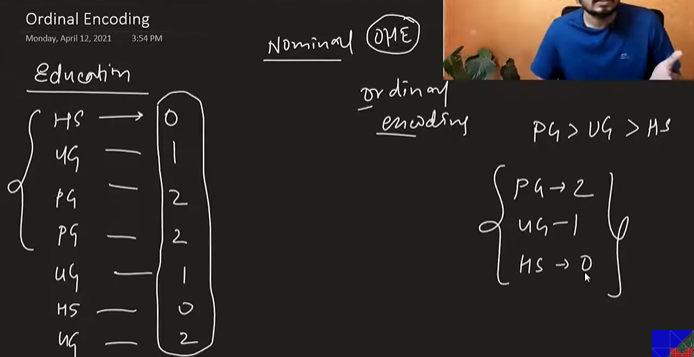

In [1]:
import pandas as pd
import numpy as np


In [3]:
df=pd.read_csv('customer.csv')
df.sample(5)

,age,gender,review,education,purchased
10,98,Female,Good,UG,Yes
44,77,Female,Average,UG,No
11,74,Male,Good,UG,Yes
29,83,Female,Average,UG,Yes
4,16,Female,Average,UG,No


In [4]:
#Age is a numerical column
# gender- nominal encoding
# review,education-ordinal encoding
# purcased- label encoding( No hierarcy)(y/n)

In [6]:
df=pd.read_csv('customer.csv',usecols=['review','education','purchased'])
df.sample(5)

,review,education,purchased
40,Good,School,No
21,Average,PG,No
27,Poor,PG,No
48,Good,UG,Yes
14,Poor,PG,Yes


In [7]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.iloc[:,0:2],df.iloc[:,-1],test_size=0.2)

In [8]:
x_train

,review,education
12,Poor,School
28,Poor,School
35,Poor,School
31,Poor,School
39,Poor,PG
33,Good,PG
6,Good,School
10,Good,UG
24,Average,PG
0,Average,School


In [13]:
from sklearn.preprocessing import OrdinalEncoder

In [14]:
# make an object that contains the order of data
oe=OrdinalEncoder(categories=[['Poor','Average','Good'],['School','UG','PG']])

In [15]:
oe.fit(x_train)

,categories,"[['Poor', 'Average', ...], ['School', 'UG', ...]]"
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,unknown_value,None
,encoded_missing_value,nan
,min_frequency,None
,max_categories,None


In [16]:
x_train=oe.transform(x_train)
x_test=oe.transform(x_test)
x_train

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 2.],
       [2., 2.],
       [2., 0.],
       [2., 1.],
       [1., 2.],
       [1., 0.],
       [2., 0.],
       [0., 1.],
       [2., 2.],
       [0., 2.],
       [0., 2.],
       [2., 0.],
       [0., 2.],
       [2., 1.],
       [1., 0.],
       [1., 0.],
       [1., 1.],
       [0., 1.],
       [2., 2.],
       [0., 2.],
       [0., 2.],
       [2., 0.],
       [1., 1.],
       [2., 0.],
       [2., 0.],
       [0., 1.],
       [1., 0.],
       [1., 2.],
       [1., 2.],
       [2., 1.],
       [2., 1.],
       [1., 1.],
       [0., 1.],
       [0., 2.],
       [1., 1.],
       [2., 2.]])

In [17]:
from sklearn.preprocessing import LabelEncoder

In [19]:
le=LabelEncoder()

In [20]:
le.fit(y_train)

LabelEncoder()

In [21]:
y_train=le.transform(y_train)
y_test=le.transform(y_test)

In [22]:
y_train

array([0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1])